# Clase 3: Regresión Lineal, Regresión Logística y Métricas de Clasificación

## Ejemplos prácticos para la clase

---
## 1. Regresión Lineal Simple

Encontrar la mejor línea recta: `y = mx + b`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset de casas
casas = pd.read_csv("casas.csv")

# Regresión simple: precio en función de m2
X = casas[["m2"]]
y = casas["precio"]

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# Fórmula aprendida
print(f"Fórmula aprendida: precio = {modelo.coef_[0]:.2f} x m² + {modelo.intercept_:.2f}")
print(f"Interpretación: cada m² extra agrega USD {modelo.coef_[0]:.0f} al precio")

Fórmula aprendida: precio = 535.24 x m² + 41954.92
Interpretación: cada m² extra agrega USD 535 al precio


/Users/javierguignard/Documents/ANT 2026/01-fundamentos-ia-ml/teorico/.env01/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


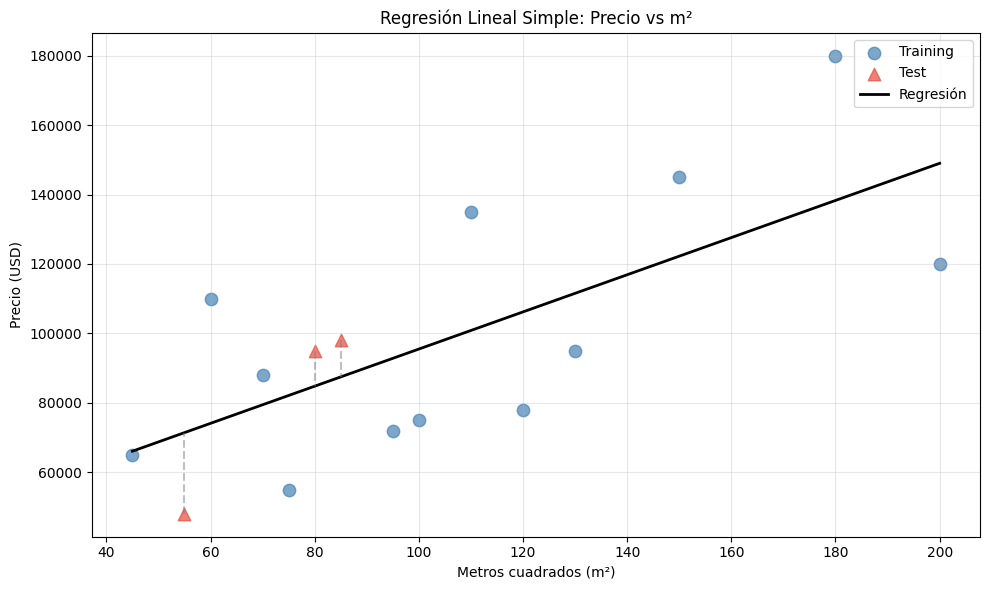

Las líneas grises punteadas son los RESIDUOS (errores de predicción)


In [2]:
# Visualizar la regresión

plt.figure(figsize=(10, 6))

# Datos de entrenamiento
plt.scatter(X_train, y_train, color="steelblue", s=80, label="Training", alpha=0.7)
# Datos de test
plt.scatter(X_test, y_test, color="#e74c3c", s=80, label="Test", marker="^", alpha=0.7)

# Línea de regresión
x_line = np.linspace(X["m2"].min(), X["m2"].max(), 100).reshape(-1, 1)
plt.plot(x_line, modelo.predict(x_line), color="black", linewidth=2, label="Regresión")

# Mostrar residuos en los puntos de test
for xi, yi, yp in zip(X_test.values, y_test.values, y_pred):
    plt.plot([xi[0], xi[0]], [yi, yp], color="gray", linestyle="--", alpha=0.5)

plt.xlabel("Metros cuadrados (m²)")
plt.ylabel("Precio (USD)")
plt.title("Regresión Lineal Simple: Precio vs m²")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Las líneas grises punteadas son los RESIDUOS (errores de predicción)")

---
## 2. Métricas de Regresión: MSE, RMSE, R²

In [3]:
# Calcular métricas

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("MÉTRICAS DE REGRESIÓN")
print("=" * 50)
print(f"MSE  = {mse:,.2f}")
print(f"       → Error cuadrático medio (penaliza errores grandes)")
print(f"\nRMSE = {rmse:,.2f}")
print(f"       → En las mismas unidades que el precio (USD)")
print(f"       → 'En promedio, nos equivocamos por USD {rmse:,.0f}'")
print(f"\nR²   = {r2:.4f}")
print(f"       → El modelo explica el {r2:.0%} de la variación en los precios")
print(f"       → 1.0 = perfecto, 0.0 = no explica nada")

MÉTRICAS DE REGRESIÓN
MSE  = 254,368,431.95
       → Error cuadrático medio (penaliza errores grandes)

RMSE = 15,948.93
       → En las mismas unidades que el precio (USD)
       → 'En promedio, nos equivocamos por USD 15,949'

R²   = 0.5148
       → El modelo explica el 51% de la variación en los precios
       → 1.0 = perfecto, 0.0 = no explica nada


---
## 3. Gradient Descent (visualización)

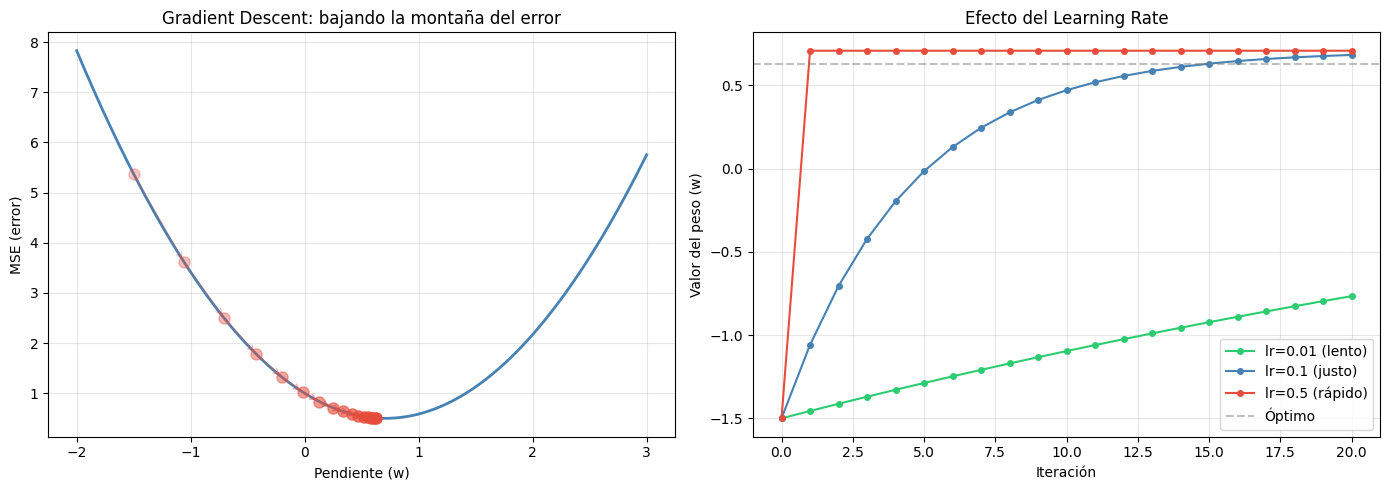

In [4]:
# Visualización simplificada de Gradient Descent
# Encontrar el mejor peso (pendiente) minimizando MSE

from sklearn.preprocessing import StandardScaler

# Normalizar para la demo
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_norm = scaler_x.fit_transform(casas[["m2"]]).flatten()
y_norm = scaler_y.fit_transform(casas[["precio"]]).flatten()

# Calcular MSE para distintos valores de pendiente
pendientes = np.linspace(-2, 3, 200)
mses = [np.mean((y_norm - w * X_norm) ** 2) for w in pendientes]

# Simular gradient descent
w = -1.5  # valor inicial (malo)
learning_rate = 0.1
historia = [(w, np.mean((y_norm - w * X_norm) ** 2))]

for _ in range(15):
    gradiente = -2 * np.mean(X_norm * (y_norm - w * X_norm))
    w = w - learning_rate * gradiente
    mse_actual = np.mean((y_norm - w * X_norm) ** 2)
    historia.append((w, mse_actual))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de error
axes[0].plot(pendientes, mses, color="steelblue", linewidth=2)
for i, (wi, ei) in enumerate(historia):
    alpha = 0.3 + 0.7 * (i / len(historia))
    axes[0].plot(wi, ei, "o", color="#e74c3c", markersize=8, alpha=alpha)
    if i < len(historia) - 1:
        axes[0].annotate("", xy=(historia[i+1][0], historia[i+1][1]),
                         xytext=(wi, ei),
                         arrowprops=dict(arrowstyle="->", color="#e74c3c", alpha=alpha))

axes[0].set_xlabel("Pendiente (w)")
axes[0].set_ylabel("MSE (error)")
axes[0].set_title("Gradient Descent: bajando la montaña del error")
axes[0].grid(True, alpha=0.3)

# Efecto del learning rate
for lr, color, label in [(0.01, "#2ecc71", "lr=0.01 (lento)"),
                          (0.1, "steelblue", "lr=0.1 (justo)"),
                          (0.5, "#e74c3c", "lr=0.5 (rápido)")]:
    w_temp = -1.5
    hist_temp = [w_temp]
    for _ in range(20):
        grad = -2 * np.mean(X_norm * (y_norm - w_temp * X_norm))
        w_temp = w_temp - lr * grad
        hist_temp.append(w_temp)
    axes[1].plot(hist_temp, "o-", color=color, label=label, markersize=4)

axes[1].axhline(y=historia[-1][0], color="gray", linestyle="--", alpha=0.5, label="Óptimo")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Valor del peso (w)")
axes[1].set_title("Efecto del Learning Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Regresión Lineal Múltiple

In [5]:
# Usar múltiples features para predecir

casas = pd.read_csv("casas.csv")

# Encoding del barrio (one-hot)
casas_encoded = pd.get_dummies(casas, columns=["barrio"], drop_first=True)

# Features y label
X = casas_encoded.drop("precio", axis=1)
y = casas_encoded["precio"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar
modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)

# Evaluar
y_pred = modelo_multi.predict(X_test)
print(f"Regresión Múltiple (todas las features):")
print(f"  RMSE: USD {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"  R²:   {r2_score(y_test, y_pred):.4f}")

# Pesos aprendidos
print(f"\nPesos aprendidos:")
for feature, peso in sorted(zip(X.columns, modelo_multi.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature:>20s}: {peso:>10,.2f}")
print(f"  {'Intercepto':>20s}: {modelo_multi.intercept_:>10,.2f}")

Regresión Múltiple (todas las features):
  RMSE: USD 22,159
  R²:   0.0634

Pesos aprendidos:
  barrio_Nueva Córdoba:  49,384.50
         barrio_Centro:  33,777.00
          habitaciones:  11,949.33
          barrio_Cerro:    -992.22
            antiguedad:    -784.14
                    m2:     183.01
            Intercepto:  33,753.98


In [6]:
# Comparar: regresión simple vs múltiple

# Simple (solo m2)
modelo_simple = LinearRegression()
modelo_simple.fit(X_train[["m2"]], y_train)
y_pred_simple = modelo_simple.predict(X_test[["m2"]])

print("Comparación:")
print(f"  Regresión Simple (solo m²):")
print(f"    RMSE: USD {np.sqrt(mean_squared_error(y_test, y_pred_simple)):,.0f}")
print(f"    R²:   {r2_score(y_test, y_pred_simple):.4f}")
print(f"\n  Regresión Múltiple (todas las features):")
print(f"    RMSE: USD {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print(f"    R²:   {r2_score(y_test, y_pred):.4f}")
print(f"\n→ Más features = más información = mejor predicción (en general)")

Comparación:
  Regresión Simple (solo m²):
    RMSE: USD 15,949
    R²:   0.5148

  Regresión Múltiple (todas las features):
    RMSE: USD 22,159
    R²:   0.0634

→ Más features = más información = mejor predicción (en general)


---
## 5. Regresión Logística (Clasificación)

### La función sigmoide

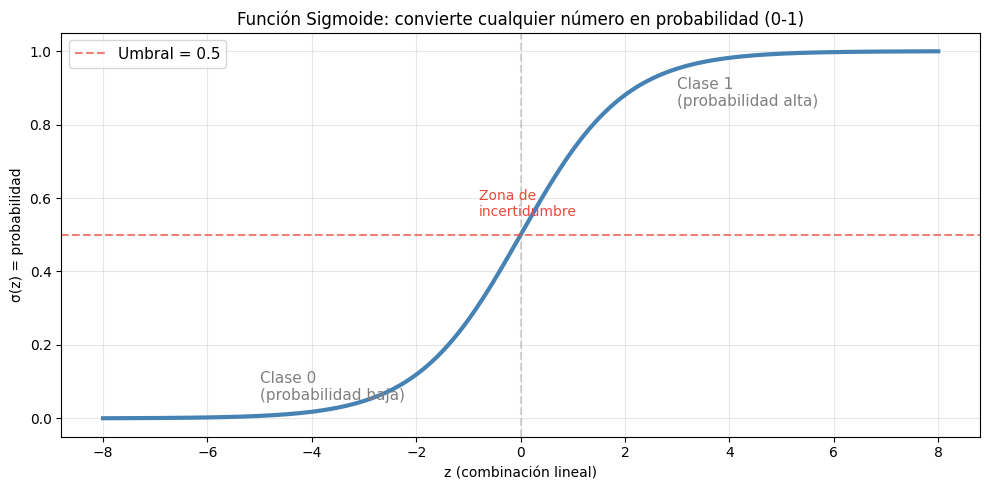

In [7]:
# Visualizar la función sigmoide

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)

plt.figure(figsize=(10, 5))
plt.plot(z, sigmoide(z), color="steelblue", linewidth=3)
plt.axhline(y=0.5, color="#e74c3c", linestyle="--", alpha=0.7, label="Umbral = 0.5")
plt.axvline(x=0, color="gray", linestyle="--", alpha=0.3)

# Anotaciones
plt.annotate("Clase 0\n(probabilidad baja)", xy=(-5, 0.05), fontsize=11, color="gray")
plt.annotate("Clase 1\n(probabilidad alta)", xy=(3, 0.85), fontsize=11, color="gray")
plt.annotate("Zona de\nincertidumbre", xy=(-0.8, 0.55), fontsize=10, color="#e74c3c")

plt.xlabel("z (combinación lineal)")
plt.ylabel("σ(z) = probabilidad")
plt.title("Función Sigmoide: convierte cualquier número en probabilidad (0-1)")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo completo: Clasificación de tumores (benigno/maligno)

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Cargar datos
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = maligno, 1 = benigno

print(f"Dataset: {X.shape[0]} muestras, {X.shape[1]} features")
print(f"Clases: 0=Maligno ({(y==0).sum()}), 1=Benigno ({(y==1).sum()})")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar (fit solo en train!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train_scaled, y_train)

# Predecir
y_pred = modelo_log.predict(X_test_scaled)
y_proba = modelo_log.predict_proba(X_test_scaled)

# Mostrar algunas predicciones con probabilidades
print(f"\nPrimeras 10 predicciones:")
print(f"{'Real':>8} {'Predicho':>10} {'P(Maligno)':>12} {'P(Benigno)':>12}")
print("-" * 45)
for i in range(10):
    real = "Benigno" if y_test[i] == 1 else "Maligno"
    pred = "Benigno" if y_pred[i] == 1 else "Maligno"
    print(f"{real:>8} {pred:>10} {y_proba[i][0]:>12.1%} {y_proba[i][1]:>12.1%}")

Dataset: 569 muestras, 30 features
Clases: 0=Maligno (212), 1=Benigno (357)

Primeras 10 predicciones:
    Real   Predicho   P(Maligno)   P(Benigno)
---------------------------------------------


---
## 6. Métricas de Clasificación

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

# Accuracy
print("=" * 50)
print("MÉTRICAS DE CLASIFICACIÓN")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

In [ ]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Visualización de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Maligno", "Benigno"])
disp.plot(cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de Confusión")

# Explicación visual
axes[1].axis("off")
explicacion = (
    f"TP (True Positive)  = {cm[1][1]:>3d}  →  Predijo Benigno y ERA Benigno\n"
    f"TN (True Negative)  = {cm[0][0]:>3d}  →  Predijo Maligno y ERA Maligno\n"
    f"FP (False Positive)  = {cm[0][1]:>3d}  →  Predijo Benigno pero ERA Maligno\n"
    f"FN (False Negative) = {cm[1][0]:>3d}  →  Predijo Maligno pero ERA Benigno\n\n"
    f"Precision = TP/(TP+FP) = {cm[1][1]}/{cm[1][1]+cm[0][1]} = {precision_score(y_test, y_pred):.2%}\n"
    f"Recall    = TP/(TP+FN) = {cm[1][1]}/{cm[1][1]+cm[1][0]} = {recall_score(y_test, y_pred):.2%}"
)
axes[1].text(0.1, 0.5, explicacion, fontsize=12, family="monospace",
             verticalalignment="center", transform=axes[1].transAxes)
axes[1].set_title("Explicación")

plt.tight_layout()
plt.show()

In [ ]:
# Reporte completo

print("REPORTE COMPLETO (classification_report):")
print(classification_report(y_test, y_pred, target_names=["Maligno", "Benigno"]))

---
## 7. El problema de la Accuracy con datos desbalanceados

In [ ]:
# Simulemos un dataset de fraude bancario: 99% legítimo, 1% fraude

from sklearn.datasets import make_classification

X_fraude, y_fraude = make_classification(
    n_samples=10000, n_features=10, n_informative=5,
    weights=[0.99, 0.01],  # 99% clase 0, 1% clase 1
    random_state=42
)

print(f"Transacciones legítimas: {(y_fraude==0).sum()} ({(y_fraude==0).mean():.1%})")
print(f"Transacciones fraudulentas: {(y_fraude==1).sum()} ({(y_fraude==1).mean():.1%})")

# Un modelo que SIEMPRE dice "no fraude"
y_pred_tonto = np.zeros_like(y_fraude)

print(f"\nModelo 'tonto' (siempre dice NO FRAUDE):")
print(f"  Accuracy:  {accuracy_score(y_fraude, y_pred_tonto):.2%}  ← ¡Parece excelente!")
print(f"  Precision: {precision_score(y_fraude, y_pred_tonto, zero_division=0):.2%}")
print(f"  Recall:    {recall_score(y_fraude, y_pred_tonto):.2%}  ← ¡No detecta NINGÚN fraude!")
print(f"  F1-Score:  {f1_score(y_fraude, y_pred_tonto):.2%}")

print(f"\n→ 99% de accuracy pero completamente INÚTIL.")
print(f"→ Por eso accuracy sola NO ALCANZA con datos desbalanceados.")

---
## 8. Precision vs Recall: el trade-off

In [ ]:
from sklearn.metrics import precision_recall_curve

# Usar las probabilidades del modelo de cáncer
precision_vals, recall_vals, umbrales = precision_recall_curve(y_test, y_proba[:, 1])

plt.figure(figsize=(10, 5))
plt.plot(umbrales, precision_vals[:-1], color="steelblue", linewidth=2, label="Precision")
plt.plot(umbrales, recall_vals[:-1], color="#e74c3c", linewidth=2, label="Recall")
plt.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral por defecto (0.5)")

plt.xlabel("Umbral de decisión")
plt.ylabel("Score")
plt.title("Trade-off Precision vs Recall según Umbral")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Si bajamos el umbral → sube Recall, baja Precision (más falsos positivos)")
print("Si subimos el umbral → sube Precision, baja Recall (se escapan positivos)")
print("\nEl umbral óptimo depende del CONTEXTO del problema.")

In [ ]:
# Ejemplo: cambiar el umbral según el contexto

print("=" * 60)
print("EFECTO DE CAMBIAR EL UMBRAL (dataset de cáncer)")
print("=" * 60)
print(f"\n{'Umbral':>8} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 42)

for umbral in [0.2, 0.3, 0.5, 0.7, 0.9]:
    y_custom = (y_proba[:, 1] >= umbral).astype(int)
    p = precision_score(y_test, y_custom, zero_division=0)
    r = recall_score(y_test, y_custom)
    f = f1_score(y_test, y_custom, zero_division=0)
    print(f"{umbral:>8.1f} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

print(f"\nDetección de cáncer → umbral BAJO (0.2-0.3) → priorizar Recall")
print(f"Filtro de spam → umbral ALTO (0.7-0.9) → priorizar Precision")

---
## Resumen

| Modelo | Tipo | Salida | Métrica clave |
|--------|------|--------|---------------|
| Regresión Lineal | Regresión | Número continuo | MSE, RMSE, R² |
| Regresión Logística | Clasificación | Probabilidad → clase | Precision, Recall, F1 |

| Métrica | Fórmula | Priorizar cuando... |
|---------|---------|---------------------|
| Precision | TP / (TP + FP) | Falso positivo es costoso (spam) |
| Recall | TP / (TP + FN) | Falso negativo es peligroso (cáncer) |
| F1 | 2 x (P x R) / (P + R) | Necesitás balance |